In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [4]:
df.head()

,CustomerID,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

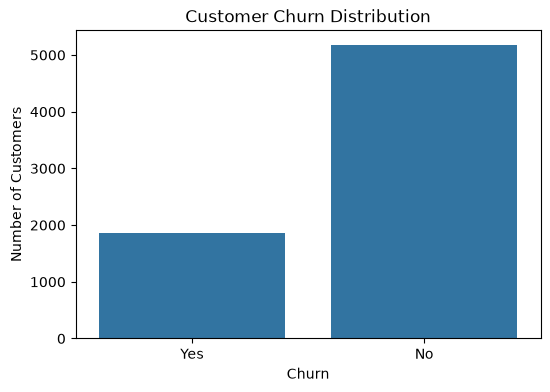

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn Label")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

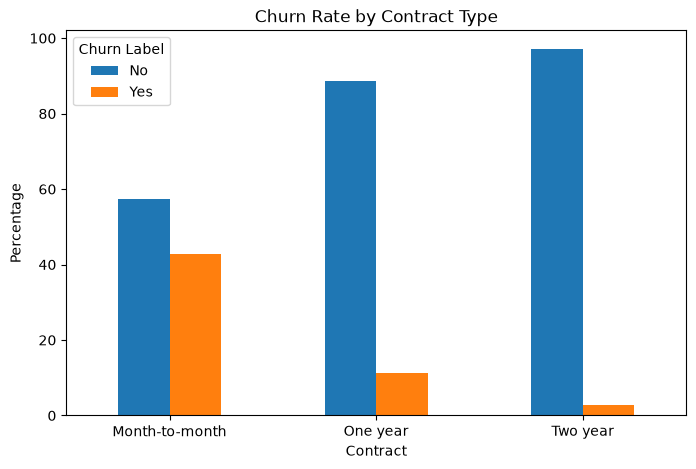

In [10]:
#Does customer contract type differ in observed churn rate?
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [14]:
def plot_churn_rate_by_category(df, column):
    ct = pd.crosstab(df[column], df["Churn Label"], normalize="index") * 100
    
    print(f"=== Churn Rate by {column} (%) ===")
    display(ct)
    
    ct.plot(kind="bar", figsize=(7, 4))
    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=0 if df[column].nunique() <= 3 else 45)
    plt.legend(title="Churn Label")
    plt.show()

=== Churn Rate by Internet Service (%) ===


Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


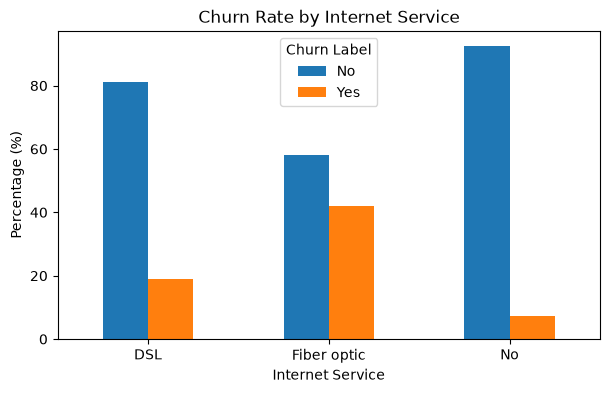

In [15]:
plot_churn_rate_by_category(df, "Internet Service")

=== Churn Rate by Payment Method (%) ===


Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


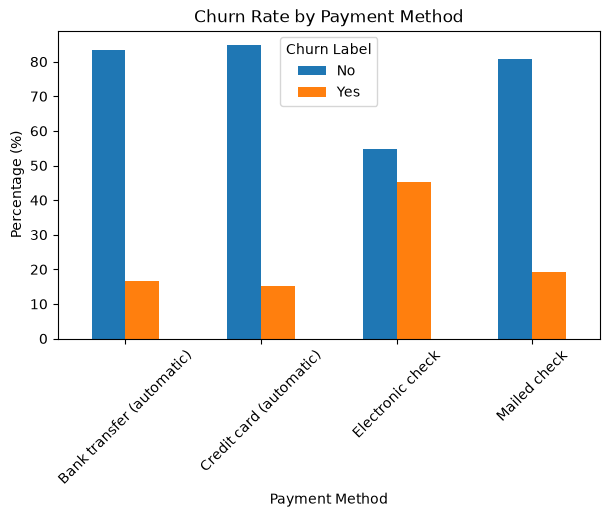

In [16]:
#Does observed churn vary by payment method?
plot_churn_rate_by_category(df, "Payment Method")

=== Churn Rate by Tech Support (%) ===


Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


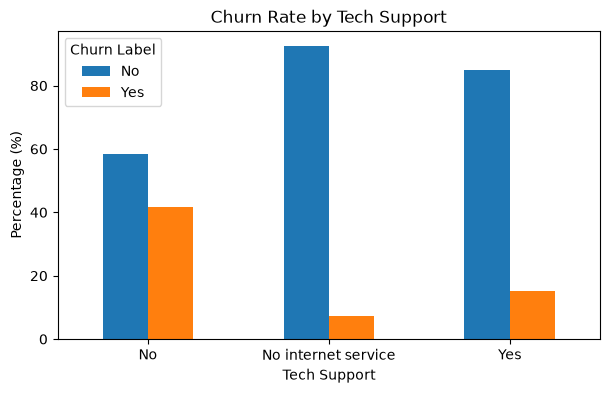

In [17]:
#How does churn vary according to Tech Support subscription?
plot_churn_rate_by_category(df, "Tech Support")

=== Churn Rate by Online Security (%) ===


Churn Label,No,Yes
Online Security,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


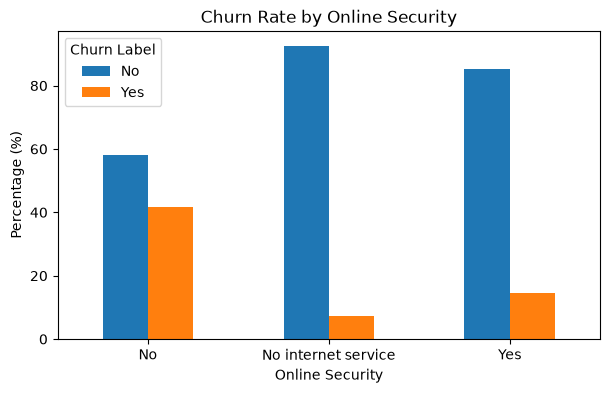

In [18]:
#Are customers without additional services generally more likely to churn?
plot_churn_rate_by_category(df, "Online Security")

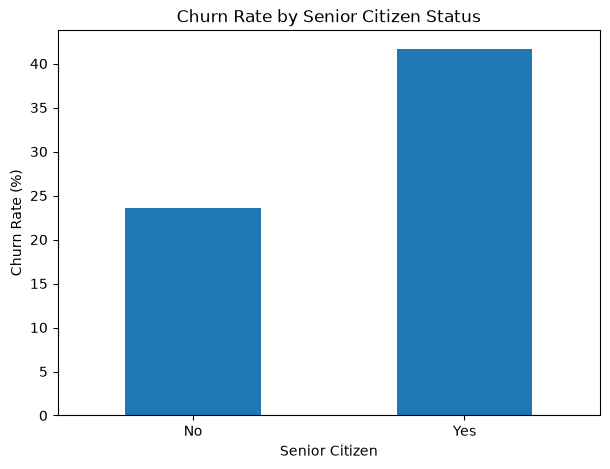

In [34]:
senior_churn = (
    pd.crosstab(
        df["Senior Citizen"],
        df["Churn Label"],
        normalize="index"
    ) * 100
)

senior_churn["Yes"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

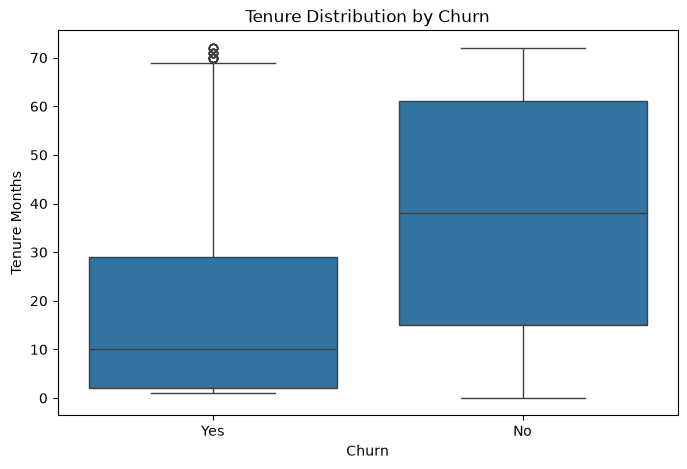

In [19]:
#Does customer tenure differ between churned and retained customers?
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")

plt.show()

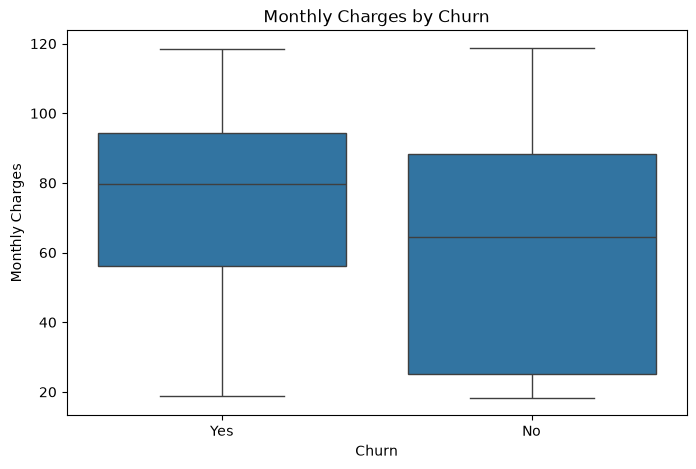

In [20]:
#How do monthly charges differ between churned and retained customers?
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

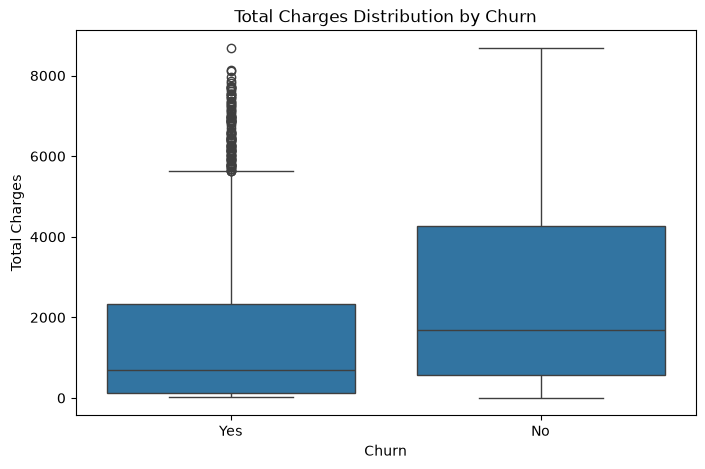

In [21]:
#How do cumulative charges differ between churned and retained customers?
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges"
)
plt.title("Total Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

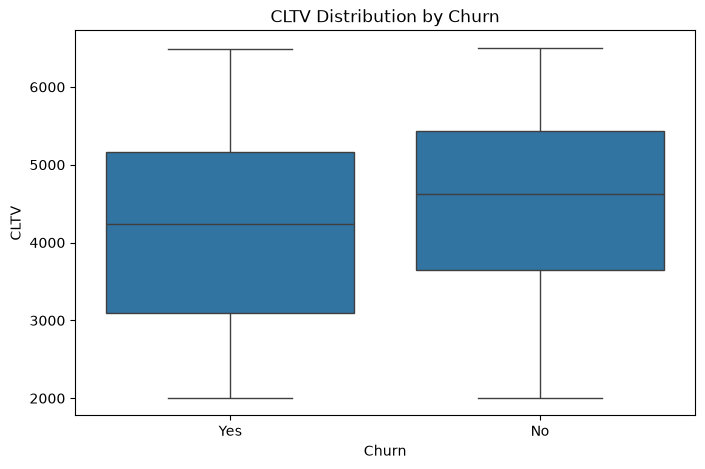

In [22]:
#How does customer lifetime value differ between churned and retained customers?
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)
plt.title("CLTV Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("CLTV")
plt.show()

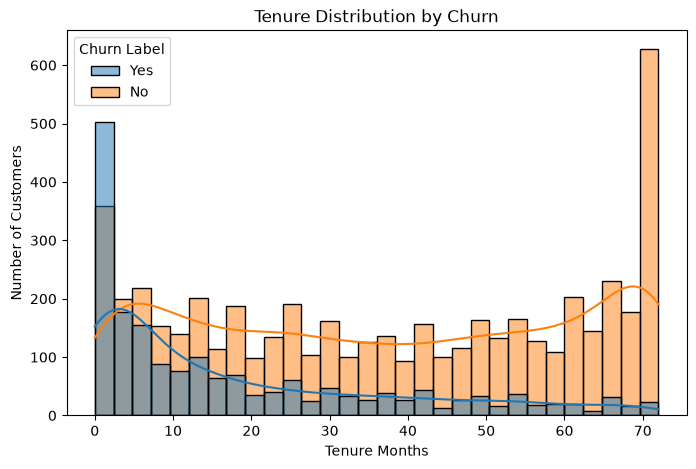

In [23]:
#Where in the customer lifecycle is churn most concentrated?
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")

plt.show()

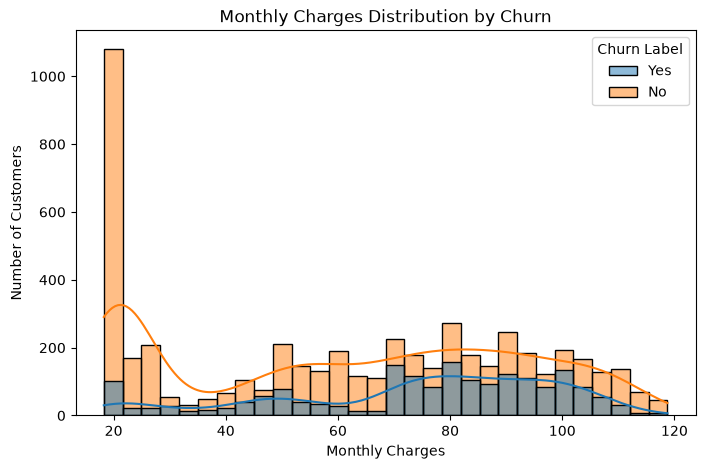

In [24]:
#Is churn concentrated in specific monthly charge ranges?
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Monthly Charges",
    hue="Churn Label",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

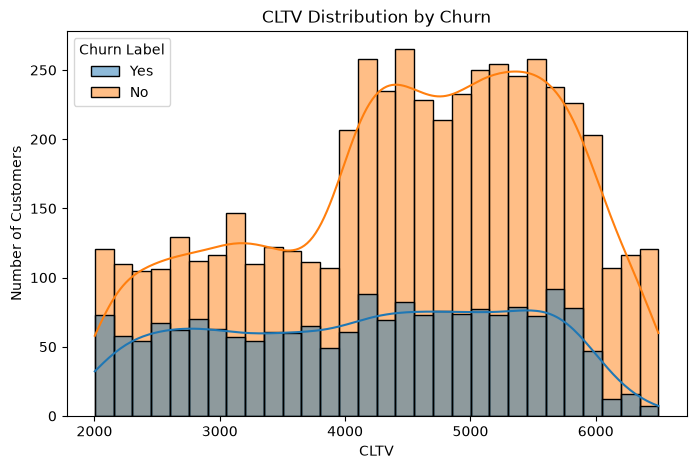

In [25]:
#Does CLTV provide clear separation between churned and retained customers?
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="CLTV",
    hue="Churn Label",
    bins=30,
    kde=True
)

plt.title("CLTV Distribution by Churn")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")

plt.show()

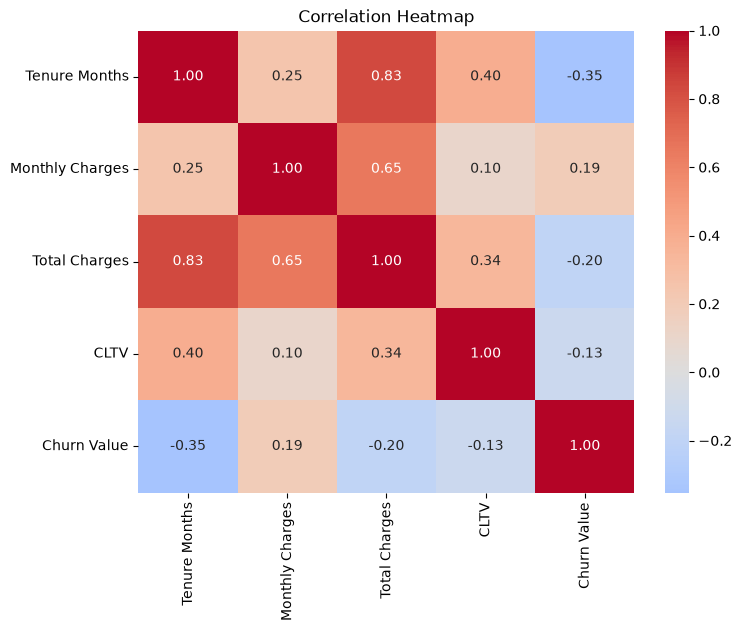

In [28]:
corr_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

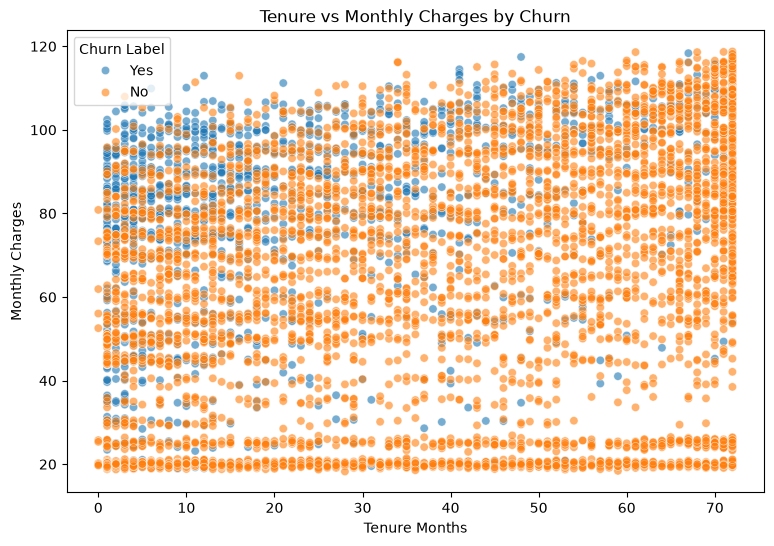

In [33]:
#How are tenure and monthly charges distributed together across churn groups?
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Tenure Months",
    y="Monthly Charges",
    hue="Churn Label",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure Months")
plt.ylabel("Monthly Charges")

plt.show()

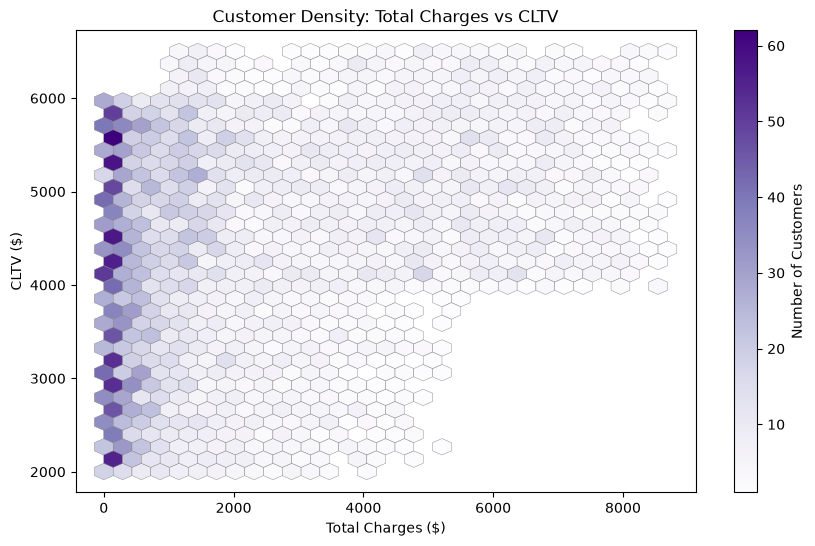

In [41]:
plt.figure(figsize=(10, 6))

hb = plt.hexbin(
    df["Total Charges"],
    df["CLTV"],
    gridsize=30,
    cmap="Purples",     
    edgecolors="gray",
    linewidths=0.3,
    mincnt=1
)

cb = plt.colorbar(hb, label="Number of Customers")

plt.xlabel("Total Charges ($)")
plt.ylabel("CLTV ($)")
plt.title("Customer Density: Total Charges vs CLTV")

plt.show()

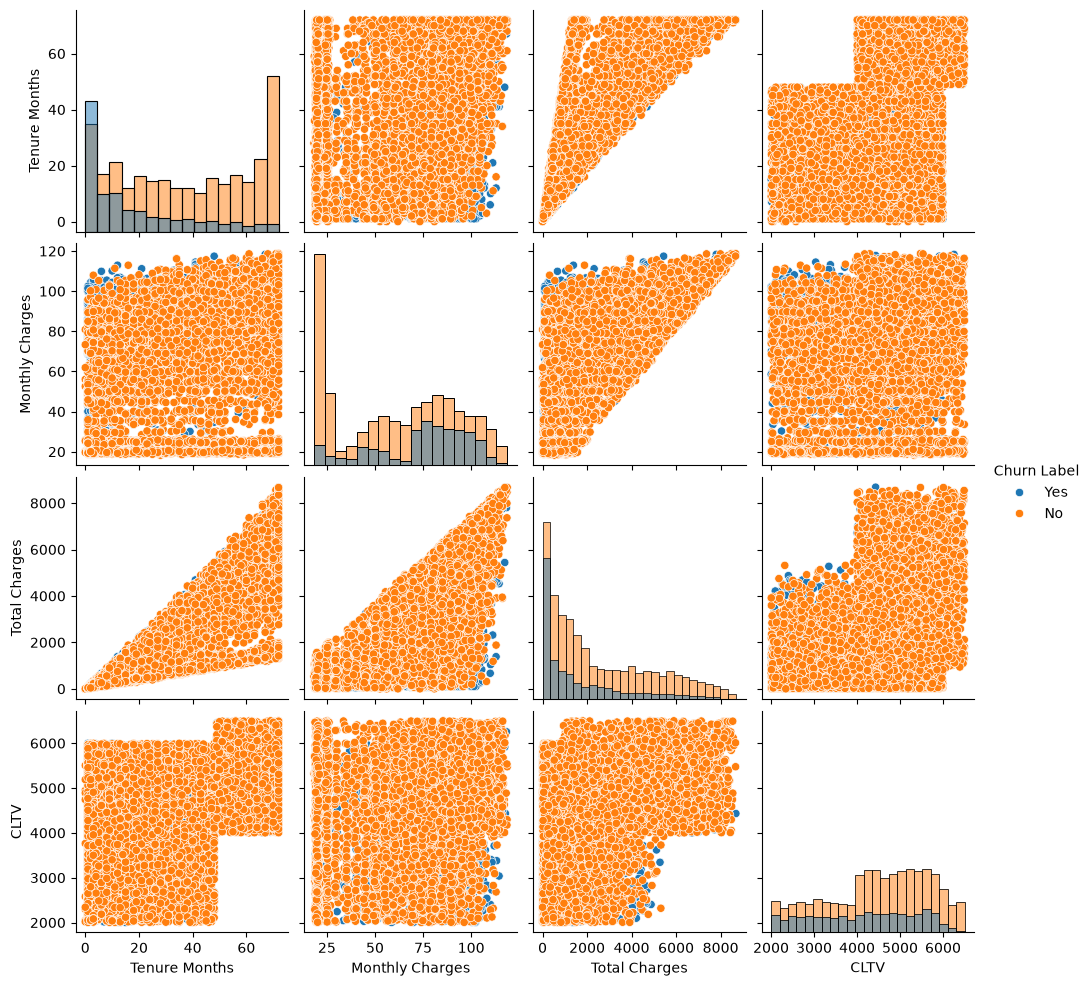

In [31]:
pairplot_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Label"
]

sns.pairplot(
    df[pairplot_cols],
    hue="Churn Label",
    diag_kind="hist"
)

plt.show()

In [42]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [43]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Tenure Months,9.00,55.00,-60.000,124.000,0,0.0
1,Monthly Charges,35.50,89.85,-46.025,171.375,0,0.0
2,Total Charges,398.55,3786.60,-4683.525,8868.675,0,0.0
3,CLTV,3469.00,5380.50,601.750,8247.750,0,0.0


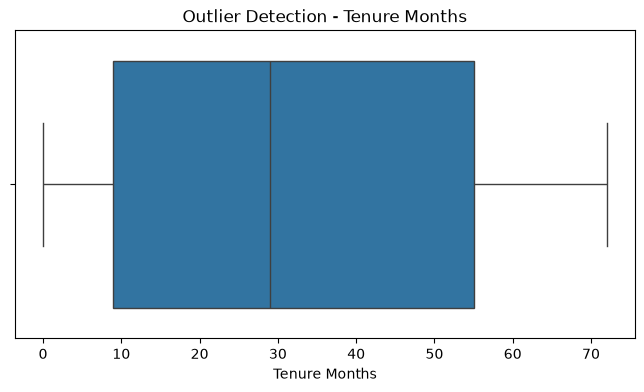

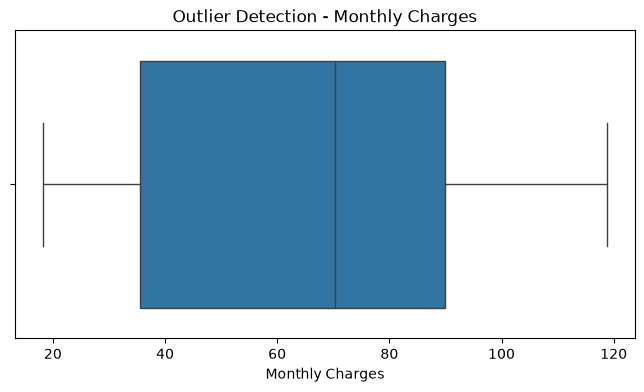

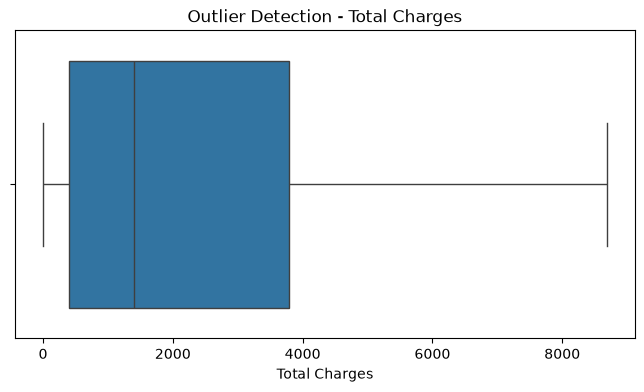

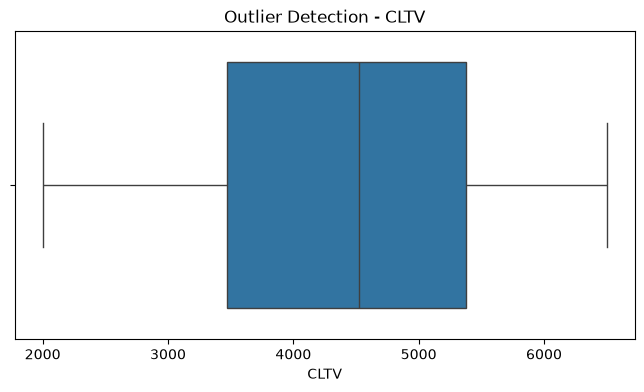

In [44]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Detection - {col}")
    plt.xlabel(col)

    plt.show()

##  Exploratory Data Analysis (EDA) Summary

---

### 1. Dataset Overview & Target Distribution
* **Dataset Size:** 7,043 unique customer records.
* **Target Distribution:** 
  * **Retained (No):** ~73.5% (5,174 customers)
  * **Churned (Yes):** ~26.5% (1,869 customers)
* **Modeling Note:** The target variable is **moderately imbalanced**. Evaluation must rely on metrics like **Recall, Precision, F1-Score, and PR-AUC** rather than raw Accuracy.

---

### 2. Customer Tenure & Charges
* **Tenure:** Churned customers have significantly shorter tenure compared to retained customers (churn is concentrated in early customer lifecycles).
* **Monthly Charges:** Churned customers show higher median monthly charges in the observed data.
* **Total Charges:** Retained customers display higher cumulative charges, strongly driven by their longer tenure ($r = 0.83$ between Tenure and Total Charges).

---

### 3. Contract & Service Offerings
* **Contract Type:** *Month-to-month* customers exhibit substantially higher observed churn rates compared to *One-year* or *Two-year* contract holders.
* **Internet Service:** *Fiber Optic* users demonstrate a higher observed churn rate than *DSL* or *No Internet* service users.
* **Add-on Services:** Customers without **Tech Support** or **Online Security** show higher observed churn rates than those subscribed to these services.

---

### 4. Payment Behavior
* **Payment Method:** Customers utilizing **Electronic Check** show a substantially higher observed churn rate compared to other payment options (Credit Card, Bank Transfer, Mailed Check).

---

### 5. Customer Lifetime Value (CLTV)
* **Separation Capability:** CLTV distributions show substantial overlap between churned and retained customers.
* **Correlation:** Linear correlation with Churn Value is weak ($r = -0.13$), indicating CLTV alone does not provide strong class separation for churn classification.

---

###  Outlier Assessment
* An **IQR-based outlier analysis** ($1.5 \times IQR$) was performed on all continuous features:
  * `Tenure Months`: **0 outliers**
  * `Monthly Charges`: **0 outliers**
  * `Total Charges`: **0 outliers**
  * `CLTV`: **0 outliers**
* **Conclusion:** No outlier removal or capping is required for these numerical variables.

---

###  Key Modeling Implications & Feature Policy

1. **Candidate Features for Classification:**
   * `Contract`, `Tenure Months`, `Monthly Charges`, `Internet Service`, `Payment Method`, `Tech Support`, `Online Security`, and other behavioral attributes show strong predictive signal.

2. **Excluded Features (Leakage & Identifiers Audit):**
   * `CustomerID` $\rightarrow$ Identifier (Drop).
   * `Churn Value` $\rightarrow$ Duplicate Target (Drop).
   * `Churn Score` $\rightarrow$ Existing model score / Target-derived info (Drop).
   * `Churn Reason` $\rightarrow$ Post-churn outcome information (Drop).
   * `CLTV` $\rightarrow$ Reserved as the Target for the Regression Notebook.